# 02 — Feature Engineering
Analyze feature importance, selection, and potential new features.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/heart.csv')
print(df.shape)

(918, 12)


## 1. Encode & Split

In [2]:
df_enc = df.copy()
df_enc['Sex'] = df_enc['Sex'].map({'M':1,'F':0})
df_enc['ExerciseAngina'] = df_enc['ExerciseAngina'].map({'Y':1,'N':0})
df_enc = pd.get_dummies(df_enc, columns=['ChestPainType','RestingECG','ST_Slope'], drop_first=True)

X = df_enc.drop('HeartDisease', axis=1)
y = df_enc['HeartDisease']
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 734 | Test: 184


## 2. Random Forest Feature Importance

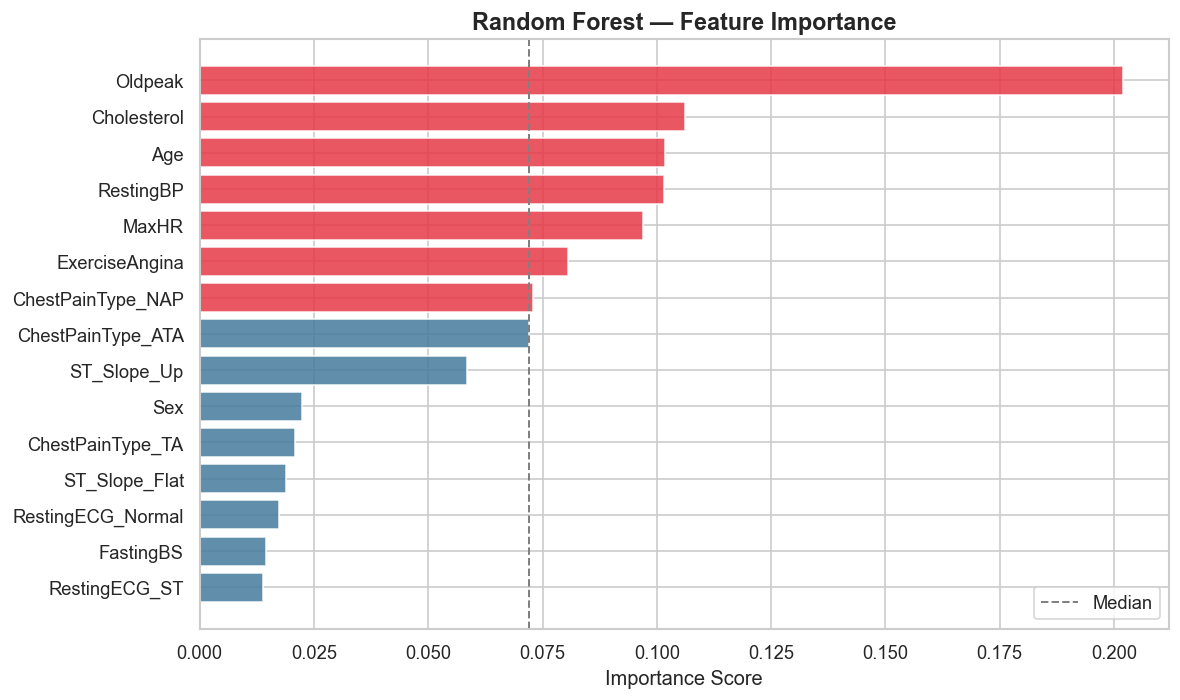

In [3]:
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e63946' if importances[i] > np.median(importances) else '#457b9d' for i in idx]
ax.barh([feature_names[i] for i in idx][::-1],
        importances[idx][::-1], color=colors[::-1], alpha=0.85)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
ax.axvline(np.median(importances), color='gray', ls='--', lw=1.2, label='Median')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Permutation Importance (more reliable)

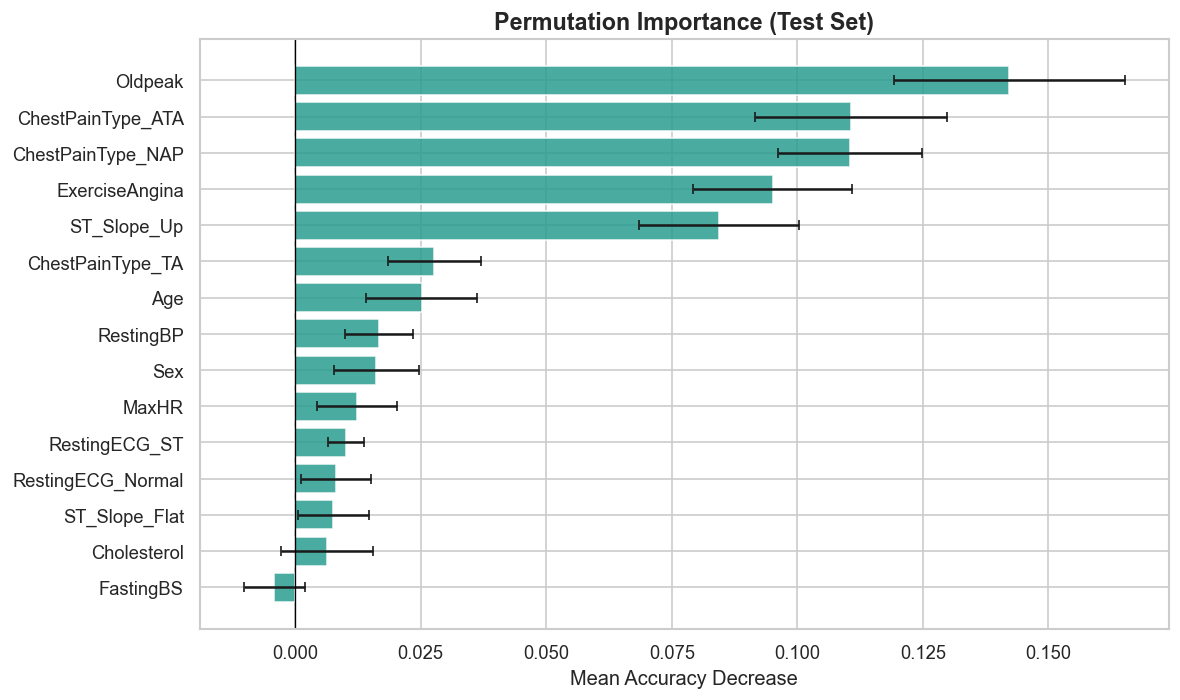


Top 5 most important features:
              feature  importance       std
7             Oldpeak    0.142210  0.022976
8   ChestPainType_ATA    0.110688  0.019163
9   ChestPainType_NAP    0.110507  0.014402
6      ExerciseAngina    0.095109  0.015798
14        ST_Slope_Up    0.084420  0.015859


In [4]:
perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df['feature'][::-1], perm_df['importance'][::-1],
        xerr=perm_df['std'][::-1], color='#2a9d8f', alpha=0.85, capsize=3)
ax.set_xlabel('Mean Accuracy Decrease', fontsize=12)
ax.set_title('Permutation Importance (Test Set)', fontsize=14, fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(perm_df.head())

## 4. Correlation with Target

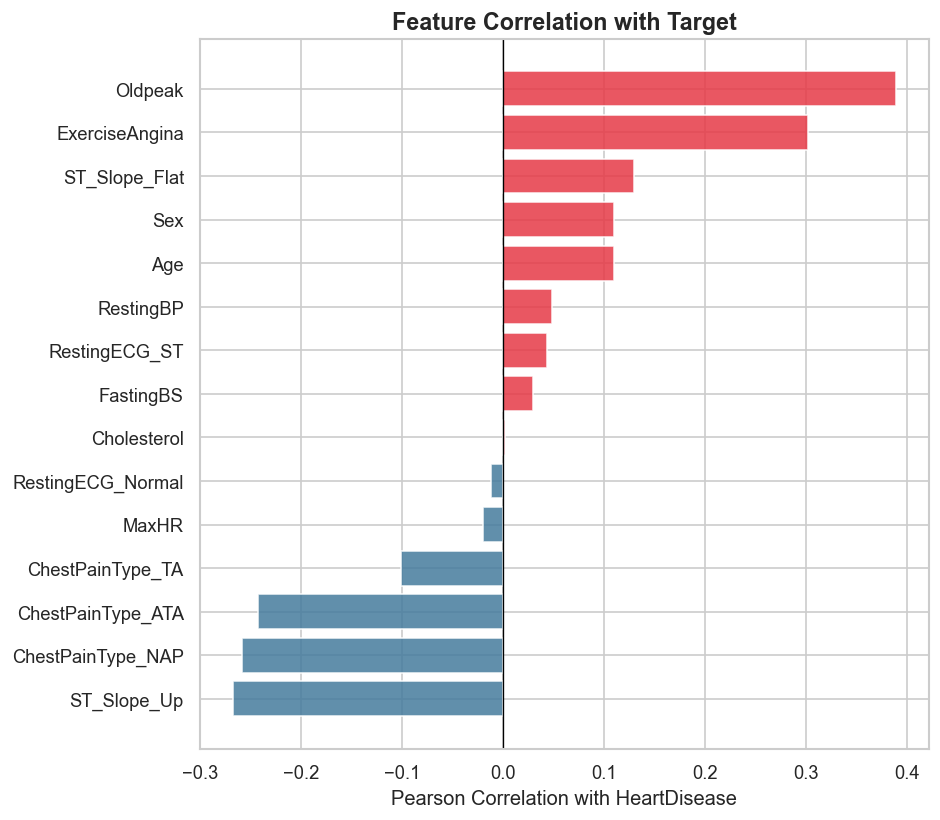

In [5]:
corr_with_target = df_enc.corr()['HeartDisease'].drop('HeartDisease').sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#e63946' if c > 0 else '#457b9d' for c in corr_with_target]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson Correlation with HeartDisease', fontsize=12)
ax.set_title('Feature Correlation with Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Potential New Features (Feature Engineering Ideas)

Disease rate by AgeGroup:
AgeGroup
<40      46.8%
40-55    43.5%
55-70    59.3%
70+      54.2%
Name: HeartDisease, dtype: object

Disease rate — HighRiskFlag:
HighRiskFlag
0    41.5%
1    87.3%
Name: HeartDisease, dtype: object


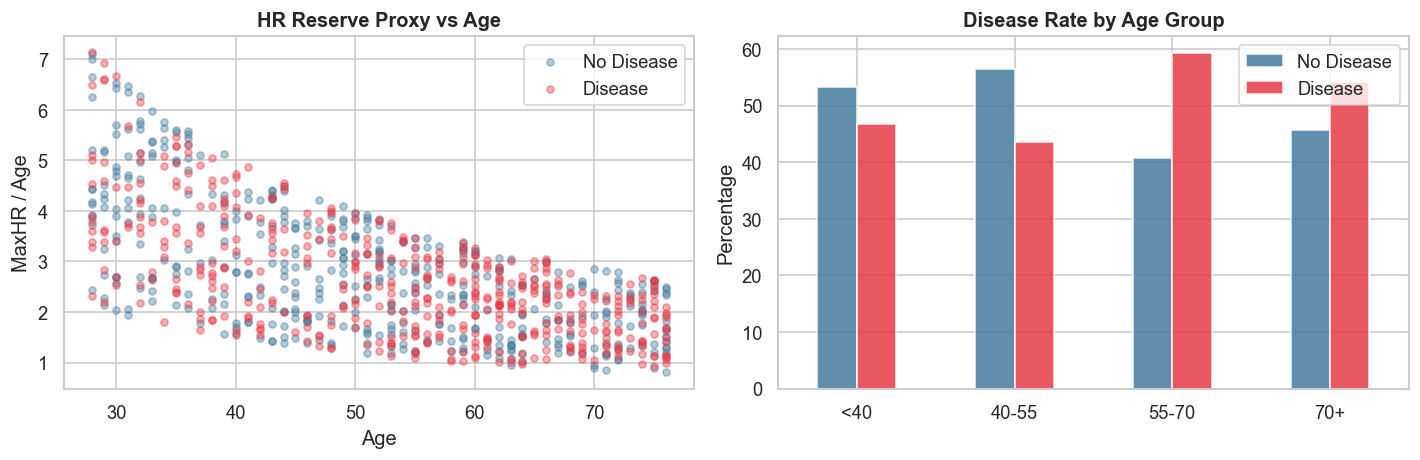

In [6]:
df_fe = df.copy()

# Age group
df_fe['AgeGroup'] = pd.cut(df_fe['Age'], bins=[0,40,55,70,100],
                            labels=['<40','40-55','55-70','70+'])

# HR reserve proxy (max HR decreases with age; simple proxy)
df_fe['HRReserveProxy'] = df_fe['MaxHR'] / df_fe['Age']

# High risk flag: ASY chest pain + exercise angina
df_fe['HighRiskFlag'] = ((df_fe['ChestPainType']=='ASY') & (df_fe['ExerciseAngina']=='Y')).astype(int)

print('Disease rate by AgeGroup:')
print(df_fe.groupby('AgeGroup')['HeartDisease'].mean().map('{:.1%}'.format))
print('\nDisease rate — HighRiskFlag:')
print(df_fe.groupby('HighRiskFlag')['HeartDisease'].mean().map('{:.1%}'.format))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for target, color in [(0,'#457b9d'),(1,'#e63946')]:
    axes[0].scatter(
        df_fe[df_fe['HeartDisease']==target]['Age'],
        df_fe[df_fe['HeartDisease']==target]['HRReserveProxy'],
        alpha=0.4, color=color, s=18,
        label='No Disease' if target==0 else 'Disease'
    )
axes[0].set_xlabel('Age'); axes[0].set_ylabel('MaxHR / Age')
axes[0].set_title('HR Reserve Proxy vs Age', fontweight='bold')
axes[0].legend()

ct = pd.crosstab(df_fe['AgeGroup'], df_fe['HeartDisease'], normalize='index')*100
ct.plot(kind='bar', ax=axes[1], color=['#457b9d','#e63946'], alpha=0.85, width=0.5)
axes[1].set_title('Disease Rate by Age Group', fontweight='bold')
axes[1].set_ylabel('Percentage'); axes[1].set_xlabel('')
axes[1].legend(['No Disease','Disease'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()